## Final Project

Create your own <span style='color:blue '> ***machine-learning model*** </span>

Using your chosen dataset, perform predictive analytics by following these steps. <br>
1. Load the dataset and place it in a `data frame`.
2. Describe your dataset by answering the following questions.
   * What are the `dimensions` of your dataset?
   * What are the features (`data dictionary`)?
   * What are the `data types` of each feature?
   * Are there `null` or `invalid` values?
   * Are there `duplicates`?
   * What are the `statistics` of your dataset?
3. Provide `insights` from your dataset by creating `aggregations` (`groupby`) and `charts`.
4. Perform `Feature Engineering` to prepare your data prior modeling.
5. Perform `Forecasting` or `Classification` using the machine-learning models we discussed.
6. Evaluate the `performance` of your models using the different metrics we discussed.
7. Provide your `insights` and `observations` in each step.
8. Provide your conclusion and recommendations based on your findings.
9. Save the notebook in this format: <span style='color:blue '>Final Project - Last Name, First Name.ipynb</span>
10. Upload your notebook in the assignment section in Canvas.

***Goodluck!***

### Project Background / Overview

<span style="color: green; font-size: 15px;">This project focuses on analyzing a medical dataset to identify the key factors that contribute to heart attacks. The dataset includes patient health metrics such as age, gender, heart rate, blood pressure, blood sugar, CK-MB, and troponin levels. By applying data analysis and predictive modeling techniques, the goal is to determine which variables are most associated with heart attack cases (indicated in the dataset as a positive result). This project aims to support early detection and prevention efforts by providing data-driven insights that can help improve healthcare outcomes and decision-making.</span>

### I. Dataset

In [72]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

<span style="color: green; font-size: 20px;">1. Load the dataset and place it in a data frame:</span>

In [73]:
DataSet = pd.read_csv('Medicaldataset.csv')

### II. Data Preparation

In [4]:
DataSet

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result
0,63,1,66,160,83,160.0,1.80,0.012,negative
1,20,1,94,98,46,296.0,6.75,1.060,positive
2,56,1,64,160,77,270.0,1.99,0.003,negative
3,66,1,70,120,55,270.0,13.87,0.122,positive
4,54,1,64,112,65,300.0,1.08,0.003,negative
...,...,...,...,...,...,...,...,...,...
1314,44,1,94,122,67,204.0,1.63,0.006,negative
1315,66,1,84,125,55,149.0,1.33,0.172,positive
1316,45,1,85,168,104,96.0,1.24,4.250,positive
1317,54,1,58,117,68,443.0,5.80,0.359,positive


<span style="color: green; font-size: 20px;">2.1. What are the dimensions of your dataset?</span>

In [88]:
print(f"Dimensions: {DataSet.shape[0]} rows, {DataSet.shape[1]} columns")

Dimensions: 1319 rows, 9 columns


<span style="color: green; font-size: 20px;">2.2. What are the features (data dictionary)?</span>

<span style="color: teal; font-weight: bold;">
# Column Name &nbsp;&nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Data Type &nbsp;&nbsp;&nbsp;&nbsp;&nbsp; Definition
</span>

<pre>
# Age                      int64         Age of the patient in years.
# Gender                   int64         Gender of the patient (0 = Female, 1 = Male).
# Heart rate               int64         Heart rate of the patient in bpm.
# Systolic blood pressure  int64         Upper blood pressure in mmHg.
# Diastolic blood pressure int64         Lower blood pressure in mmHg.
# Blood sugar              float64       Blood sugar level in mg/dL.
# CK-MB                    float64       Heart muscle enzyme (ng/mL).
# Troponin                 float64       Protein marker for heart damage (ng/mL).
# Result                   object        Heart attack status (positive/negative).
</pre>


In [89]:
print(DataSet.columns)

Index(['Age', 'Gender', 'Heart rate', 'Systolic blood pressure',
       'Diastolic blood pressure', 'Blood sugar', 'CK-MB', 'Troponin',
       'Result'],
      dtype='object')


<span style="color: green; font-size: 20px;">2.3. What are the data types of each feature?</span>

In [90]:
print(DataSet.dtypes)

Age                           int64
Gender                        int64
Heart rate                    int64
Systolic blood pressure       int64
Diastolic blood pressure      int64
Blood sugar                 float64
CK-MB                       float64
Troponin                    float64
Result                       object
dtype: object


<span style="color: green; font-size: 20px;">2.4. Are there null or invalid values?</span>

In [91]:
DataSet.isnull().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [92]:
DataSet.isna().sum()

Age                         0
Gender                      0
Heart rate                  0
Systolic blood pressure     0
Diastolic blood pressure    0
Blood sugar                 0
CK-MB                       0
Troponin                    0
Result                      0
dtype: int64

In [93]:
DataSet.notnull().sum()

Age                         1319
Gender                      1319
Heart rate                  1319
Systolic blood pressure     1319
Diastolic blood pressure    1319
Blood sugar                 1319
CK-MB                       1319
Troponin                    1319
Result                      1319
dtype: int64

<span style="color: green; font-size: 20px;">2.5. Are there duplicates?</span>

In [51]:
DataSet.duplicated().sum()

np.int64(0)

In [52]:
duplicates = DataSet[DataSet.duplicated()]
duplicates

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result


<span style="color: green; font-size: 20px;">2.6. What are the statistics of your dataset?</span>

In [53]:
DataSet.describe()

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin
count,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000,1319.000000
mean,56.193328,0.659591,78.336619,127.170584,72.269143,146.634344,15.274306,0.360942
std,13.638173,0.474027,51.630270,26.122720,14.033924,74.923045,46.327083,1.154568
min,14.000000,0.000000,20.000000,42.000000,38.000000,35.000000,0.321000,0.001000
25%,47.000000,0.000000,64.000000,110.000000,62.000000,98.000000,1.655000,0.006000
50%,58.000000,1.000000,74.000000,124.000000,72.000000,116.000000,2.850000,0.014000
75%,65.000000,1.000000,85.000000,143.000000,81.000000,169.500000,5.805000,0.085500
max,103.000000,1.000000,1111.000000,223.000000,154.000000,541.000000,300.000000,10.300000


### III. EDA (Exploratory Data Analysis)

<span style="color: green; font-size: 20px;">3. Provide insights from your dataset by creating aggregations (groupby) and charts.</span>

In [19]:
sns.set(style="whitegrid")

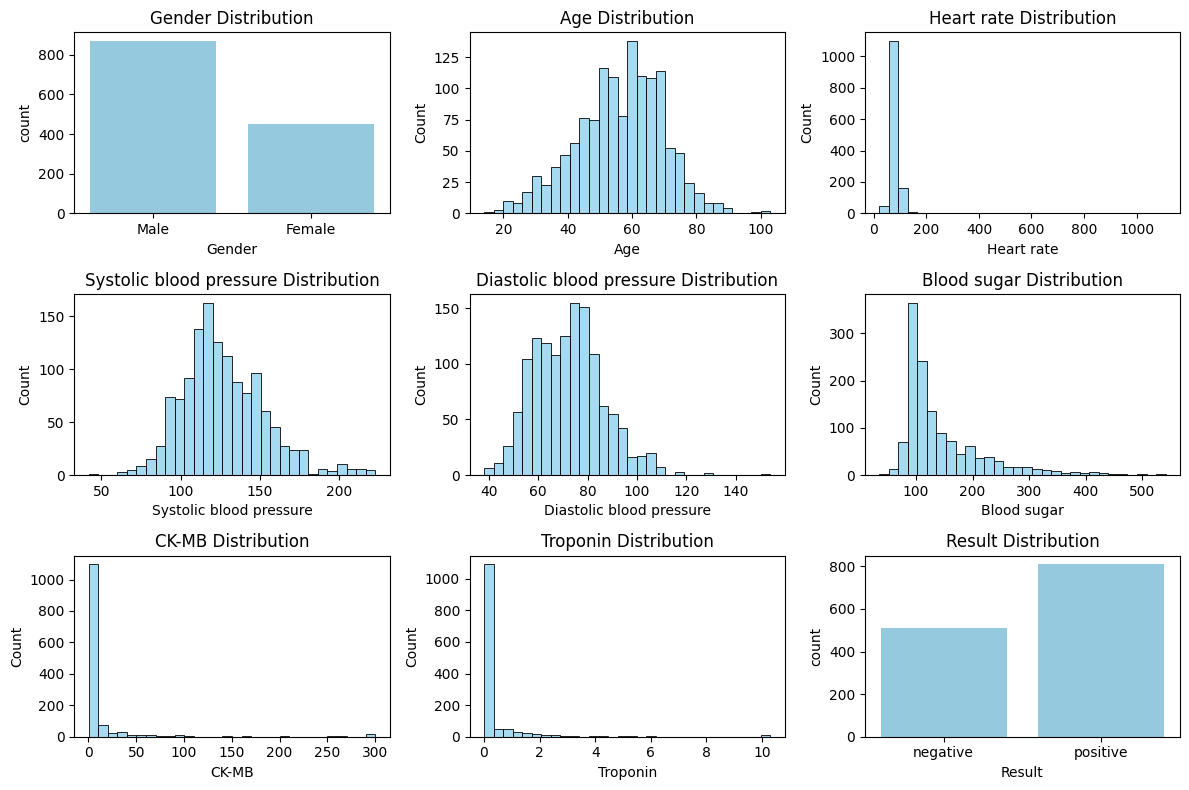

In [27]:
DataSet['Gender'] = DataSet['Gender'].replace({0: 'Female', 1: 'Male'})

features_basic = [
    "Gender",
    "Age",
    "Heart rate",
    "Systolic blood pressure",
    "Diastolic blood pressure",
    "Blood sugar",
    "CK-MB",
    "Troponin",
    "Result"
]

plt.figure(figsize=(12, 8))

for i, feature in enumerate(features_basic, 1):
    plt.subplot(3, 3, i)
    if DataSet[feature].dtype == 'object':
        sns.countplot(data=DataSet, x=feature, color='skyblue')
    else:
        sns.histplot(data=DataSet, x=feature, bins=30, kde=False, color='skyblue')
    plt.title(f'{feature} Distribution')

plt.tight_layout()
plt.show()


The distribution graphs provide a comprehensive overview of the dataset, highlighting key patterns across patient demographics and health indicators. Most patients are **male** and between **40 to 70 years old**, aligning with common heart disease risk factors. **Heart rate**, **systolic**, and **diastolic blood pressures** mostly fall within **normal or slightly elevated ranges**, though **outliers**—especially in **heart rate** and **blood sugar**—suggest potential data anomalies or severe cases. Both **CK-MB** and **troponin** levels show that while the majority of patients have **normal readings**, a significant portion exhibits **elevated values**, indicating possible **heart muscle damage**. Lastly, the **result distribution** reveals more **positive heart attack cases** than negative, suggesting a **class imbalance** that should be addressed in **predictive modeling** to ensure fairness and accuracy.

### 📊 Why Include Frequency Tables If Graphs Are Already Shown?

Even with graphs, **frequency tables** are useful because they:

- 📌 Show **exact values** — not just visual estimates.
- 🔍 Make it easy to **compare categories** side by side.
- 📈 Help in **reporting, analysis, and feature engineering**.
- ✅ Support **data validation** (e.g., spotting imbalances or outliers).

In short, graphs give the **big picture**, but tables provide the **specifics**—both are essential for clear, complete analysis.


In [75]:
age_bins = [10, 20, 30, 40, 50, 60, 70, 80, 90, 110]
age_labels = ['10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s+']

DataSet['Age_Group'] = pd.cut(DataSet['Age'], bins=age_bins, labels=age_labels, right=False)

age_group_freq = DataSet['Age_Group'].value_counts().sort_index().rename("Frequency").to_frame()
age_group_freq

,Frequency
Age_Group,
10s,4
20s,49
30s,99
40s,231
50s,316
60s,384
70s,197
80s,32
90s+,7


## 🧠 Age Group (Age_Group)

- The majority of patients are in their **60s (384)** and **50s (316)**.
- This suggests that **middle-aged to senior individuals** are the most represented in this dataset.
- These groups may need **special focus** during predictive modeling due to higher representation.


In [58]:
DataSet['Result'] = DataSet['Result'].astype(str)
result_count = DataSet['Result'].value_counts().sort_index().rename("Frequency").to_frame()

result_count

,Frequency
Result,
negative,509
positive,810


## 💖 Result (Heart Attack Occurrence)

- **Positive cases (810)** are higher than **Negative (509)**.
- The dataset has a **slight class imbalance**, which might affect model training.
- **Resampling techniques** or **weighted models** could help maintain predictive accuracy.


In [59]:
gender_count = DataSet['Gender'].replace({1: 'Male', 0: 'Female'}).value_counts().sort_index().rename("Frequency").to_frame()

gender_count 

,Frequency
Gender,
Female,449
Male,870


## 🧍‍♀️🧍 Gender

- **Males (870)** outnumber **Females (449)** nearly 2:1.
- This gender imbalance may affect how patterns show up in analysis.
- Since gender plays a role in heart disease risk, this skew should be **accounted for** in model fairness.


In [20]:
sbp_bins_image = pd.cut(DataSet['Systolic blood pressure'],
                        bins=[0, 119, 129, 139, 180, 250],
                        labels=[
                            'Normal (<120)',
                            'Elevated (120-129)',
                            'High BP Stage 1 (130-139)',
                            'High BP Stage 2 (140-180)',
                            'Hypertensive Crisis (>180)'
                        ],
                        right=True)

sbp_binned_freq_image = sbp_bins_image.value_counts().sort_index().rename("Frequency").to_frame()
sbp_binned_freq_image.index.name = "Systolic BP Range"
sbp_binned_freq_image

,Frequency
Systolic BP Range,
Normal (<120),561
Elevated (120-129),218
High BP Stage 1 (130-139),153
High BP Stage 2 (140-180),349
Hypertensive Crisis (>180),38


## 🩺 Systolic Blood Pressure (Systolic BP Range)

- Most patients fall in the **Normal (<120)** category with **561** individuals.
- A significant number are in the **High BP Stage 2 (140–180)** group (**349** patients), which may indicate a higher risk for heart-related issues.
- The **Elevated (120–129)** category contains **218** patients, suggesting early signs of potential hypertension.
- Smaller yet concerning groups fall under **High BP Stage 1 (130–139)** with **153**, and **Hypertensive Crisis (>180)** with **38** cases.
- These distributions suggest that **elevated and high systolic pressure levels** could be critical **predictors of heart attack risk** and should be **prioritized in analysis and modeling**.


In [21]:
dbp_bins = pd.cut(DataSet['Diastolic blood pressure'],
                  bins=[0, 80, 90, 120, 200],
                  labels=['Normal (<80)', 'High BP Stage 1 (80-89)', 'High BP Stage 2 (90-119)', 'Hypertensive Crisis (120+)'],
                  right=False)

dbp_binned_freq = dbp_bins.value_counts().sort_index().rename("Frequency").to_frame()
dbp_binned_freq.index.name = "Diastolic BP Range"
dbp_binned_freq

,Frequency
Diastolic BP Range,
Normal (<80),928
High BP Stage 1 (80-89),245
High BP Stage 2 (90-119),143
Hypertensive Crisis (120+),3


## 🩸 Diastolic Blood Pressure (Diastolic BP Range)

- The majority of patients are in the **Normal (<80 mmHg)** range, indicating stable diastolic pressure for most individuals.
- **Elevated cases** (with diastolic pressure **<80 mmHg**, paired with elevated systolic pressure) still fall into early concern categories.
- **High BP Stage 1 (80–89 mmHg)** includes a notable number of patients, suggesting a developing risk for heart issues.
- A substantial portion fall under **High BP Stage 2 (≥90 mmHg)**, representing more serious hypertension.
- A smaller group appears in the **Hypertensive Crisis (≥120 mmHg)**, a critical condition requiring **immediate medical attention**.
- These patterns indicate that **diastolic pressure**, especially at **Stage 2 or higher**, is an **important factor in identifying cardiovascular risk**.


In [83]:
heart_rate_bins = [0, 50, 70, 90, 110, 130, DataSet['Heart rate'].max() + 1]
heart_rate_labels = [
    'Very Low (0–49)',
    'Low (50–69)',
    'Normal (70–89)',
    'Elevated (90–109)',
    'High (110–129)',
    'Very High (130+)'
]

DataSet['Heart_Rate_Group'] = pd.cut(DataSet['Heart rate'], bins=heart_rate_bins, labels=heart_rate_labels, right=False)


heart_rate_group_freq = DataSet['Heart_Rate_Group'].value_counts().sort_index().rename("Frequency").to_frame()
heart_rate_group_freq

,Frequency
Heart_Rate_Group,
Very Low (0–49),10
Low (50–69),488
Normal (70–89),585
Elevated (90–109),189
High (110–129),35
Very High (130+),12


## 💓 Heart Rate (Heart_Rate_Group)

- The majority of patients fall within the **Normal (70–89 bpm)** range (585), followed closely by the **Low (50–69 bpm)** range (488).
- **Elevated (90–109 bpm)** heart rates account for 189 individuals, which may suggest early signs of cardiovascular stress or anxiety-related spikes.
- Fewer patients fall into the **High (110–129 bpm)** and **Very High (130+ bpm)** categories (35 and 12 respectively), but these outliers could signal more serious heart conditions.
- **Very Low (0–49 bpm)** is rare (10 cases) but may indicate bradycardia or other underlying heart issues.
- These distributions highlight that while most patients show healthy or slightly low heart rates, outliers on both ends should not be ignored as they may carry **greater clinical significance**.


In [19]:
ckmb_bins = [0, 5, 10, DataSet['CK-MB'].max() + 1]
ckmb_labels = [
    'Normal (0–5 ng/mL)',
    'Mildly Elevated (5–10 ng/mL)',
    'Significantly Elevated (>10 ng/mL)'
]

DataSet['CKMB_Group'] = pd.cut(DataSet['CK-MB'], bins=ckmb_bins, labels=ckmb_labels, right=False)

ckmb_clinical_freq = DataSet['CKMB_Group'].value_counts().sort_index()
ckmb_clinical_freq = ckmb_clinical_freq.rename_axis('CK-MB Level').reset_index(name='Frequency')
ckmb_clinical_freq = ckmb_clinical_freq.set_index('CK-MB Level')

ckmb_clinical_freq

,Frequency
CK-MB Level,
Normal (0–5 ng/mL),940
Mildly Elevated (5–10 ng/mL),153
Significantly Elevated (>10 ng/mL),226


## 🧪 CK-MB Level

- **Normal levels (0–5 ng/mL)** dominate the dataset, with **940 patients**, indicating stable heart muscle enzyme activity for the majority.
- **Mildly Elevated (5–10 ng/mL)** levels are observed in **153 patients**, which could signal minor heart stress, muscle injury, or early myocardial infarction.
- **Significantly Elevated levels (>10 ng/mL)** are present in **226 patients**, a considerable number that may point to serious cardiac muscle damage.
- This distribution suggests that **CK-MB** is a potentially powerful biomarker and could be an important variable for **predictive diagnostics**.


In [18]:
troponin_bins_ng = [0, 0.04, 0.40, 1.0]
troponin_labels_ng = [
    'Normal (0–0.04 ng/mL)',
    'Borderline Elevated (0.04–0.39 ng/mL)',
    'Probable Heart Attack (>0.40 ng/mL)'
]

DataSet['Troponin_Category'] = pd.cut(DataSet['Troponin'], bins=troponin_bins_ng, labels=troponin_labels_ng, right=False)

troponin_classified_updated = DataSet['Troponin_Category'].value_counts().sort_index()
troponin_classified_updated = troponin_classified_updated.rename_axis('Troponin Category').reset_index(name='Frequency')
troponin_classified_updated = troponin_classified_updated.set_index('Troponin Category')

troponin_classified_updated

,Frequency
Troponin Category,
Normal (0–0.04 ng/mL),893
Borderline Elevated (0.04–0.39 ng/mL),207
Probable Heart Attack (>0.40 ng/mL),88


### 🧬 **Troponin Category**

- **Normal Troponin levels (0–0.04 ng/mL)** are observed in the **majority of patients (893)**, indicating no apparent heart muscle injury in most cases.
- **207 patients** fall into the **Borderline Elevated (0.04–0.39 ng/mL)** range, which might indicate **minor cardiac stress** or early stages of **heart damage**.
- **88 patients** are in the **Probable Heart Attack** category (**>0.40 ng/mL**), suggesting a **high likelihood of acute myocardial infarction**.


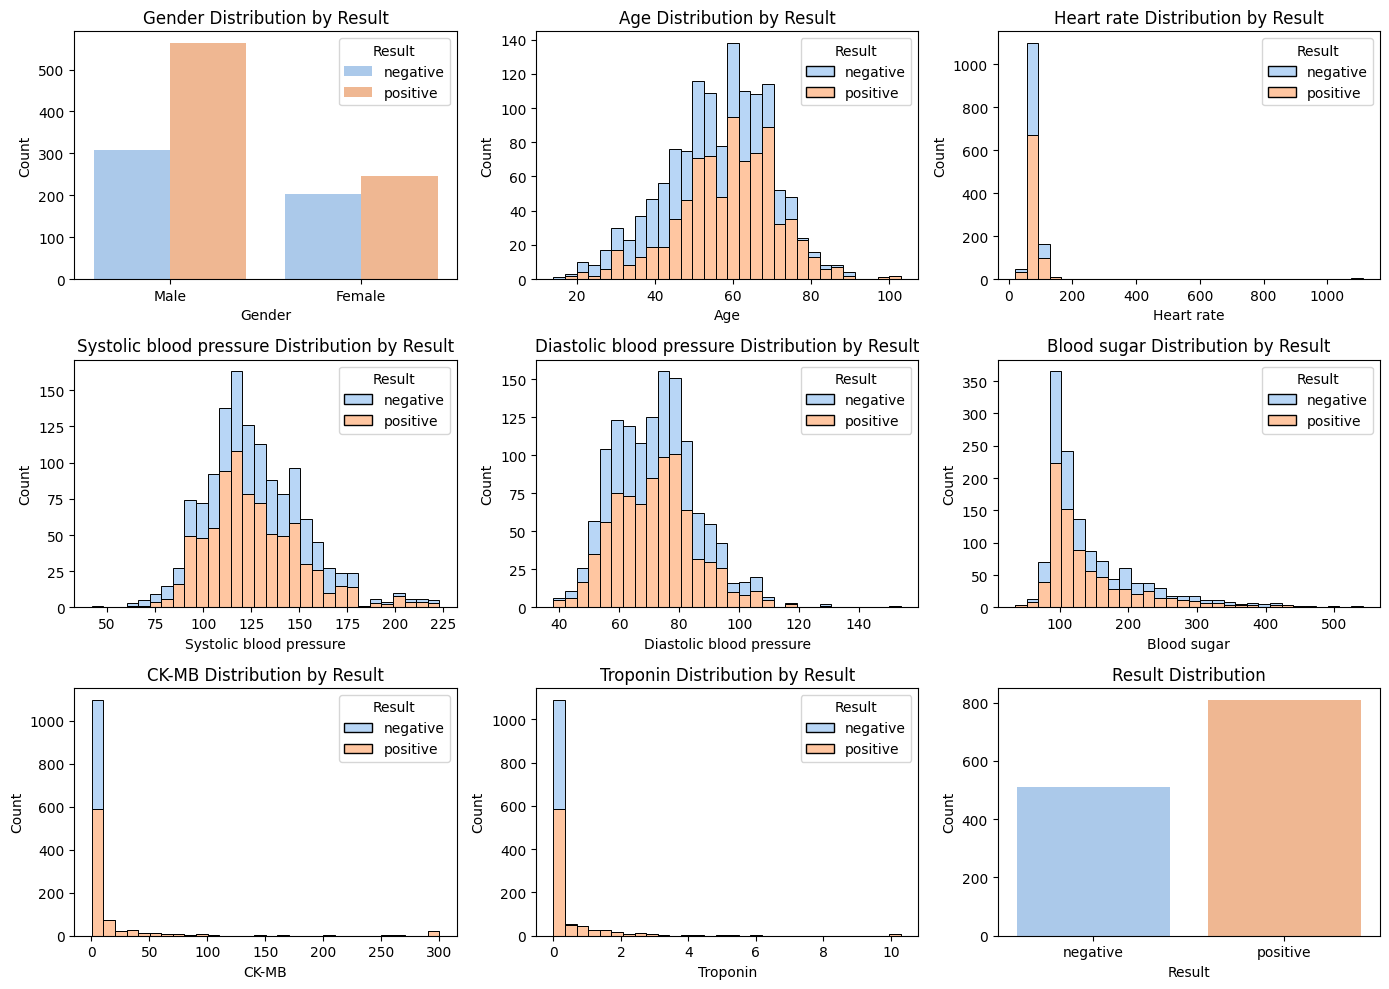

In [42]:
DataSet['Gender'] = DataSet['Gender'].replace({0: 'Female', 1: 'Male'})

features_basic = [
    "Gender",
    "Age",
    "Heart rate",
    "Systolic blood pressure",
    "Diastolic blood pressure",
    "Blood sugar",
    "CK-MB",
    "Troponin"
]

plt.figure(figsize=(14, 10))

for i, feature in enumerate(features_basic, 1):
    plt.subplot(3, 3, i)
    if DataSet[feature].dtype == 'object':
        sns.countplot(data=DataSet, x=feature, hue='Result', palette='pastel')
    else:
        sns.histplot(data=DataSet, x=feature, hue='Result', bins=30, kde=False, palette='pastel', multiple='stack')
    plt.title(f'{feature} Distribution by Result')
    plt.xlabel(feature)
    plt.ylabel("Count")

plt.subplot(3, 3, 9)
sns.countplot(data=DataSet, x="Result", hue="Result", palette='pastel', legend=False)
plt.title('Result Distribution')
plt.xlabel("Result")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

### 🔍Key Insight from Distributions by Result:  
When comparing feature distributions by heart attack outcome (positive vs. negative), several important patterns emerge. Patients with a **positive result** (indicating a heart attack) show a **noticeable shift toward higher values** in key medical features such as **systolic blood pressure, diastolic blood pressure, CK-MB, and troponin**. These biomarkers are well-established indicators of cardiovascular stress or damage, and their elevated presence aligns with clinical expectations for heart attack diagnosis.

- **Troponin and CK-MB**, both heart-specific enzymes, are significantly more elevated in the positive group, strongly reinforcing their use as reliable diagnostic indicators.
- **Blood pressure readings** (both systolic and diastolic) also trend higher in the positive group, indicating a relationship between hypertension and heart attack occurrence.
- **Heart rate and blood sugar** show more subtle shifts, suggesting a possible influence but not as strong as the other features.
- Despite the natural variation in **age and gender**, both demographics show clear distributions where middle-aged to older males dominate the positive result group.

Together, these distributions highlight which features are most closely associated with heart attack outcomes in the dataset and suggest they may serve as **strong predictors** in any predictive modeling or risk scoring systems.

# 📊 A Closer, In-Depth Look at How Certain Health Metrics Influence the Result

In [26]:
gender_result_counts = DataSet.replace({1: 'Male', 0: 'Female'}).groupby('Result')['Gender'].value_counts().unstack()

gender_result_counts

Gender,Female,Male
Result,,
negative,202,307
positive,247,563


### 🔍 Key Insight:
A higher proportion of **male patients** tested positive for heart attacks compared to females, suggesting that **males may have a higher associated risk** or more prominent indicators in this dataset.


In [33]:
age_bins = [10, 20, 30, 40, 50, 60, 70, 80, 90, 110]
age_labels = ['10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s+']

DataSet['Age_Group'] = pd.cut(DataSet['Age'], bins=age_bins, labels=age_labels, right=False)

age_group_freq = DataSet.groupby(['Age_Group', 'Result'], observed=True).size().unstack(fill_value=0)
age_group_freq

Result,negative,positive
Age_Group,,
10s,2,2
20s,30,19
30s,61,38
40s,119,112
50s,114,202
60s,129,255
70s,46,151
80s,6,26
90s+,2,5


### 🔍 Key Insight:
Heart attack cases significantly increase from the **50s to 70s age groups**, with the **60s group showing the highest number of positive results**. This suggests that **middle-aged to senior individuals are at higher risk** and should be a primary focus for predictive modeling and preventive care.


In [34]:
heart_rate_bins = [0, 50, 70, 90, 110, 130, DataSet['Heart rate'].max() + 1]
heart_rate_labels = [
    'Very Low (0–49)',
    'Low (50–69)',
    'Normal (70–89)',
    'Elevated (90–109)',
    'High (110–129)',
    'Very High (130+)'
]

DataSet['Heart_Rate_Group'] = pd.cut(DataSet['Heart rate'], bins=heart_rate_bins, labels=heart_rate_labels, right=False)

heart_rate_group_freq = DataSet.groupby(['Heart_Rate_Group', 'Result'], observed=True).size().unstack(fill_value=0)
heart_rate_group_freq

Result,negative,positive
Heart_Rate_Group,,
Very Low (0–49),4,6
Low (50–69),182,306
Normal (70–89),240,345
Elevated (90–109),64,125
High (110–129),17,18
Very High (130+),2,10


### 🔍 Key Insight:  
Patients with **low (50–69 bpm)** and **normal (70–89 bpm)** heart rates show the highest number of positive cases, but the **proportion of positive results increases with higher heart rates**, especially in the **very high (130+ bpm)** group, suggesting a potential link between elevated heart rate and heart attack risk.


In [35]:
sbp_bins_image = pd.cut(DataSet['Systolic blood pressure'],
                        bins=[0, 119, 129, 139, 180, 250],
                        labels=[
                            'Normal (<120)',
                            'Elevated (120-129)',
                            'High BP Stage 1 (130-139)',
                            'High BP Stage 2 (140-180)',
                            'Hypertensive Crisis (>180)'
                        ],
                        right=True)

DataSet['SBP_Range'] = sbp_bins_image

sbp_binned_freq_image = DataSet.groupby(['SBP_Range', 'Result'], observed=True).size().unstack(fill_value=0)
sbp_binned_freq_image.index.name = "Systolic BP Range"
sbp_binned_freq_image

Result,negative,positive
Systolic BP Range,,
Normal (<120),207,354
Elevated (120-129),76,142
High BP Stage 1 (130-139),63,90
High BP Stage 2 (140-180),150,199
Hypertensive Crisis (>180),13,25


### 🔍 Key Insight:
As systolic blood pressure increases, the number of positive heart attack cases also rises. Notably, even the **"Normal"** and **"Elevated"** categories have a high number of positives (354 and 142, respectively), but the highest proportions appear in **"High BP Stage 2"** and **"Hypertensive Crisis"** categories, reinforcing that elevated systolic BP is a significant risk factor for heart attack.

In [36]:
dbp_bins = pd.cut(DataSet['Diastolic blood pressure'],
                  bins=[0, 80, 90, 120, 200],
                  labels=['Normal (<80)', 'High BP Stage 1 (80-89)', 'High BP Stage 2 (90-119)', 'Hypertensive Crisis (120+)'],
                  right=False)

DataSet['DBP_Range'] = dbp_bins

dbp_binned_freq = DataSet.groupby(['DBP_Range', 'Result'], observed=True).size().unstack(fill_value=0)
dbp_binned_freq.index.name = "Diastolic BP Range"
dbp_binned_freq

Result,negative,positive
Diastolic BP Range,,
Normal (<80),347,581
High BP Stage 1 (80-89),99,146
High BP Stage 2 (90-119),62,81
Hypertensive Crisis (120+),1,2


### 🔍 Key Insight:
A majority of patients across **all diastolic blood pressure categories**, including hypertensive stages, tested **positive** for heart attack—suggesting that **elevated diastolic pressure** may be linked with increased cardiac risk.

In [37]:
troponin_bins_ng = [0, 0.04, 0.40, 1.0]
troponin_labels_ng = [
    'Normal (0–0.04 ng/mL)',
    'Borderline Elevated (0.04–0.39 ng/mL)',
    'Probable Heart Attack (>0.40 ng/mL)'
]

DataSet['Troponin_Category'] = pd.cut(DataSet['Troponin'], bins=troponin_bins_ng, labels=troponin_labels_ng, right=False)

troponin_classified_grouped = DataSet.groupby(['Troponin_Category', 'Result'], observed=True).size().unstack(fill_value=0)
troponin_classified_grouped.index.name = "Troponin Category"

troponin_classified_grouped

Result,negative,positive
Troponin Category,,
Normal (0–0.04 ng/mL),507,386
Borderline Elevated (0.04–0.39 ng/mL),0,207
Probable Heart Attack (>0.40 ng/mL),1,87


### 🔍 Key Insight:
Nearly all patients with **elevated troponin levels** (both borderline and probable heart attack categories) tested **positive** for heart attack. This strongly supports troponin as a **highly reliable biomarker** for detecting cardiac events.

In [12]:
ckmb_bins = [0, 5, 10, DataSet['CK-MB'].max() + 1]
ckmb_labels = [
    'Normal (0–5 ng/mL)',
    'Mildly Elevated (5–10 ng/mL)',
    'Significantly Elevated (>10 ng/mL)'
]

DataSet['CKMB_Group'] = pd.cut(DataSet['CK-MB'], bins=ckmb_bins, labels=ckmb_labels, right=False)

ckmb_clinical_freq = DataSet['CKMB_Group'].value_counts().sort_index()
ckmb_clinical_freq = ckmb_clinical_freq.rename_axis('CK-MB Level').reset_index(name='Frequency')
ckmb_clinical_freq = ckmb_clinical_freq.set_index('CK-MB Level')

ckmb_result_group = DataSet.groupby(['CKMB_Group', 'Result'], observed=True).size().unstack(fill_value=0)
ckmb_result_group

Result,negative,positive
CKMB_Group,,
Normal (0–5 ng/mL),480,460
Mildly Elevated (5–10 ng/mL),29,124
Significantly Elevated (>10 ng/mL),0,226


### 🔍 Key Insight:
Patients with **elevated CK-MB levels**, especially those in the **significantly elevated range (>10 ng/mL)**, are **exclusively positive** for heart attacks—highlighting CK-MB as a **critical biomarker** for cardiac events.

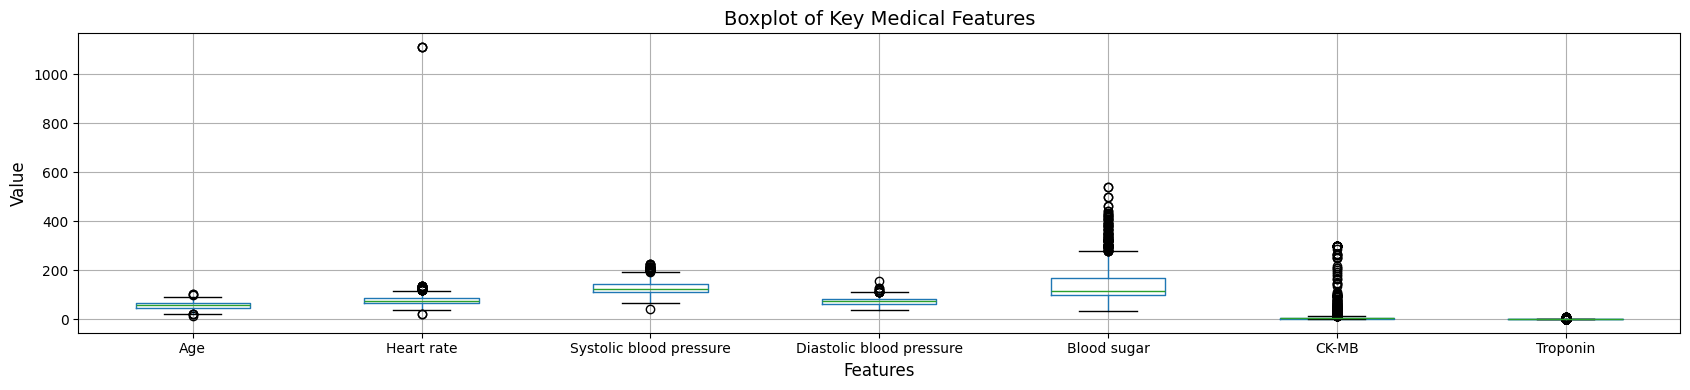

In [61]:
plt.figure(figsize=(17, 4))
DataSet[['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure',
         'Blood sugar', 'CK-MB', 'Troponin']].boxplot()

plt.title('Boxplot of Key Medical Features', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Value', fontsize=12)

plt.tight_layout()
plt.show()

The box plot reveals that most patients fall within normal to moderately elevated ranges for **age**, **heart rate**, and **blood pressure**, but several features—particularly **blood sugar**, **CK-MB**, and **troponin**—display significant outliers, indicating the presence of **high-risk or potentially critical cases**. **Heart rate** includes an extreme spike, likely an error or rare condition, while **CK-MB** and **troponin** outliers suggest possible **heart muscle damage or heart attack indicators**. Overall, the plot highlights a **skewed distribution** with a mix of typical patients and those showing **abnormal or dangerous medical signs**.


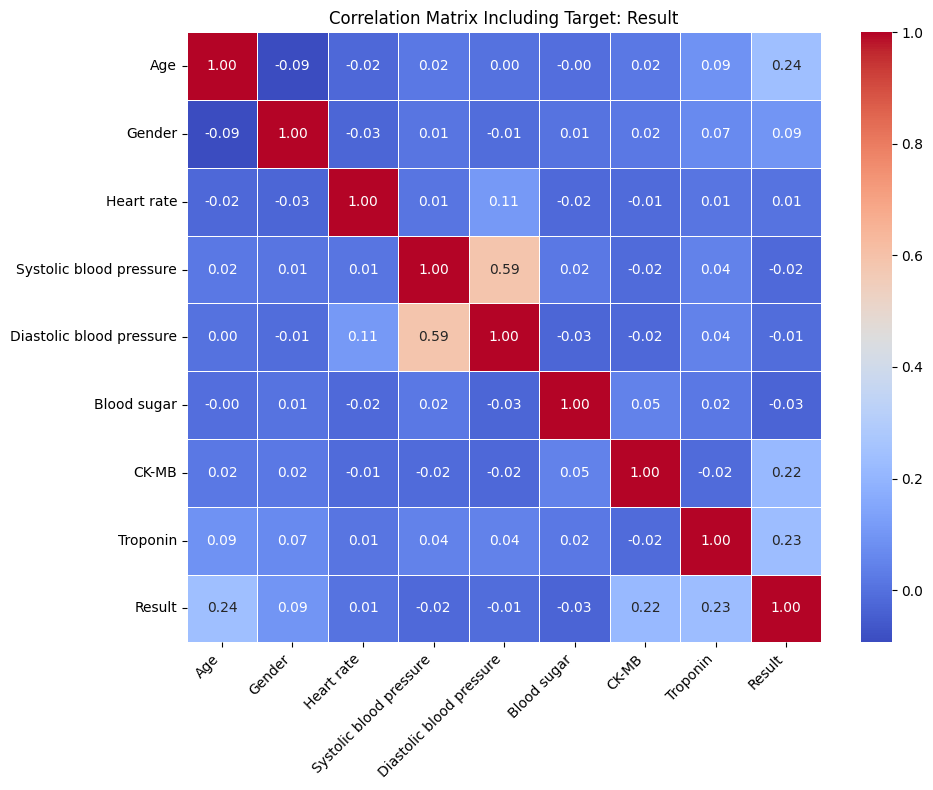

In [7]:
DataSet['Result'] = DataSet['Result'].replace({'negative': 0, 'positive': 1}).astype(int)

numeric_data = DataSet.select_dtypes(include='number')

correlation_matrix = numeric_data.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Correlation Matrix Including Target: Result")
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 🔍 Correlation Matrix Summary

This **correlation matrix** shows how strongly the numeric features in your dataset relate to each other using values from **-1 to 1**:

#### 📌 Key Takeaways:
- 🔴 **Systolic and Diastolic Blood Pressure** have a **moderate positive correlation (0.59)** – which is expected, as they're both components of blood pressure.
- 🔵 **All other correlations are weak or near zero**, suggesting:
  - Most features are **independent** of one another.
  - Variables like **Heart Rate, CK-MB, Troponin, Blood Sugar**, and **Age** don’t strongly influence each other.
- ✅ This independence is **valuable for modeling** because it means each variable might contribute **unique predictive power** without too much redundancy.


### IV. Feature Engineering

<span style="color: green; font-size: 20px;">4. Perform Feature Engineering to prepare your data prior modeling.</span>

<span style="color: green; font-size: 15px;">4.1. This code removes outliers from specific numeric health features in the dataset using the IQR method, resulting in a cleaned version (`DataSet_cleaned`) with fewer rows.</span>

In [44]:
numeric_cols = [
    'Age',
    'Heart rate',
    'Systolic blood pressure',
    'Diastolic blood pressure',
    'Blood sugar',
    'CK-MB',
    'Troponin'
]

def remove_outliers_iqr(DataSet, columns):
    for col in columns:
        Q1 = DataSet[col].quantile(0.25)
        Q3 = DataSet[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        DataSet = DataSet[(DataSet[col] >= lower_bound) & (DataSet[col] <= upper_bound)]
    return DataSet

DataSet_cleaned = remove_outliers_iqr(DataSet, numeric_cols)

In [45]:
DataSet_shape_before = DataSet.shape
DataSet_shape_after = DataSet_cleaned.shape

DataSet_shape_before, DataSet_shape_after

((1319, 9), (788, 9))

<span style="color: green; font-size: 15px;">4.2. This code segments the cleaned dataset’s Age column into age groups (like '20s', '30s', etc.) using custom bins, creating a new categorical column called `Age_Group`.
</span>

In [46]:
bins = [10, 20, 30, 40, 50, 60, 70, 80, 90, 110]
labels = ['10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s', '90s+']
DataSet_cleaned['Age_Group'] = pd.cut(DataSet_cleaned['Age'], bins=bins, labels=labels)

<span style="color: green; font-size: 15px;">4.3. This line creates a new column `Pulse_Pressure` in the cleaned dataset by subtracting Diastolic blood pressure from Systolic blood pressure, indicating the force that the heart generates with each contraction.
</span>

In [47]:
DataSet_cleaned['Pulse_Pressure'] = DataSet_cleaned['Systolic blood pressure'] - DataSet_cleaned['Diastolic blood pressure']

<span style="color: green; font-size: 15px;">4.4. This line calculates the **Mean Arterial Pressure (MAP)**, a weighted average of blood pressure that reflects overall blood flow to organs, and stores it in a new column called `MAP`.
</span>

In [48]:
DataSet_cleaned['MAP'] = (DataSet_cleaned['Systolic blood pressure'] + 2 * DataSet_cleaned['Diastolic blood pressure']) / 3

<span style="color: green; font-size: 15px;">4.5. This line computes the **CK-MB to Troponin ratio** and stores it in the `CK_Troponin_Ratio` column, using a small constant (`1e-6`) to prevent division by zero.
</span>

In [49]:
DataSet_cleaned['CK_Troponin_Ratio'] = DataSet_cleaned['CK-MB'] / (DataSet_cleaned['Troponin'] + 1e-6)

<span style="color: green; font-size: 15px;">4.6. This line creates a new column `High_BP` that flags patients with high blood pressure (systolic ≥ 140 or diastolic ≥ 90), marking them as **1 (high)** or **0 (not high)**.
</span>

In [50]:
DataSet_cleaned['High_BP'] = ((DataSet_cleaned['Systolic blood pressure'] >= 140) | 
                             (DataSet_cleaned['Diastolic blood pressure'] >= 90)).astype(int)

<span style="color: green; font-size: 15px;">4.7. This line adds a column `High_Blood_Sugar` that marks patients with blood sugar levels **≥ 180 mg/dL** as **1 (high)** and others as **0 (normal)**, indicating possible hyperglycemia.
</span>

In [51]:
DataSet_cleaned['High_Blood_Sugar'] = (DataSet_cleaned['Blood sugar'] >= 180).astype(int)

<span style="color: green; font-size: 15px;">4.8. This line creates a new feature `HeartSugar_Combo` by multiplying a patient’s heart rate and blood sugar levels, potentially highlighting combined cardiovascular and metabolic stress indicators.
</span>

In [52]:
DataSet_cleaned['HeartSugar_Combo'] = DataSet_cleaned['Heart rate'] * DataSet_cleaned['Blood sugar']

<span style="color: green; font-size: 15px;">4.9. This line creates a new column `Gender_Label` by replacing gender codes (0 and 1) with readable labels: **'Female'** for 0 and **'Male'** for 1.
</span>

In [53]:
DataSet_cleaned['Gender_Label'] = DataSet_cleaned['Gender'].replace({0: 'Female', 1: 'Male'})

<span style="color: green; font-size: 15px;">4.10. New cleaned dataset</span>


In [54]:
DataSet_cleaned

,Age,Gender,Heart rate,Systolic blood pressure,Diastolic blood pressure,Blood sugar,CK-MB,Troponin,Result,Age_Group,Pulse_Pressure,MAP,CK_Troponin_Ratio,High_BP,High_Blood_Sugar,HeartSugar_Combo,Gender_Label
0,63,1,66,160,83,160.0,1.80,0.012,negative,60s,77,108.666667,149.987501,1,0,10560.0,Male
2,56,1,64,160,77,270.0,1.99,0.003,negative,50s,83,104.666667,663.112296,1,1,17280.0,Male
5,52,0,61,112,58,87.0,1.83,0.004,negative,50s,54,76.000000,457.385654,0,0,5307.0,Female
6,38,0,40,179,68,102.0,0.71,0.003,negative,30s,111,105.000000,236.587804,1,0,4080.0,Female
8,49,0,60,154,81,135.0,2.35,0.004,negative,40s,73,105.333333,587.353162,1,0,8100.0,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1311,85,1,112,115,69,114.0,2.19,0.062,positive,80s,46,84.333333,35.322011,0,0,12768.0,Male
1312,48,1,84,118,68,96.0,5.33,0.006,negative,40s,50,84.666667,888.185302,0,0,8064.0,Male
1313,86,0,40,179,68,147.0,5.22,0.011,negative,80s,111,105.000000,474.502318,1,0,5880.0,Female
1314,44,1,94,122,67,204.0,1.63,0.006,negative,40s,55,85.333333,271.621396,0,1,19176.0,Male


<span style="color: green; font-size: 20px;">The newly created columns enhance the dataset by highlighting critical clinical indicators and improving interpretability. Features like `Pulse_Pressure` and `MAP` provide deeper insight into cardiovascular health, while `CK_Troponin_Ratio` strengthens the detection of heart damage by combining two biomarkers. Flags such as `High_BP` and `High_Blood_Sugar` help identify patients at risk due to hypertension or hyperglycemia. `HeartSugar_Combo` explores the interaction between metabolic and cardiac stress, potentially revealing hidden risk patterns. Lastly, `Gender_Label` improves readability and demographic analysis.
</span>


### V. Modeling

### 🧠 What’s Happening in the Code

The code performs a **machine learning classification task** using three models:
- **Decision Tree**
- **Random Forest**
- **Gradient Boosting**

The steps include:

1. **Data Cleaning**  
   - Outliers are removed using the Interquartile Range (IQR) method to ensure more reliable model training.

2. **Feature Engineering**  
   - New columns such as `Pulse_Pressure`, `HeartSugar_Combo`, and others are created to help the models better capture patterns in the data.

3. **Target Encoding**  
   - The `Result` column (originally text: "positive"/"negative") is converted into numeric form (`0` and `1`) so it can be processed by the machine learning models.

4. **Train-Test Split**  
   - The dataset is split into training and testing sets (80% training, 20% testing) to evaluate the model's performance on unseen data.

5. **Model Training and Prediction**  
   - Each of the three models is trained on the training data and used to make predictions on the test set.

6. **Evaluation with Confusion Matrices**  
   - Confusion matrices are generated to visualize how well each model performs, specifically showing the number of true positives, true negatives, false positives, and false negatives.

---

### 🔍 Why These Steps Are Important

- Using **multiple models** allows for performance comparison and helps identify which model is most effective for this medical dataset.
- **Feature engineering** enhances the predictive power of the models by supplying more meaningful inputs.
- **Confusion matrices** offer detailed insight beyond accuracy, showing exactly where models make errors.
- **Random Forest and Gradient Boosting** are often more accurate and robust than a single Decision Tree, and this code validates that through side-by-side comparison.


In [74]:
DataSet_cleaned['Result'] = LabelEncoder().fit_transform(DataSet_cleaned['Result'])

In [75]:
features = ['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure',
            'Blood sugar', 'CK-MB', 'Troponin', 'Pulse_Pressure',
            'High_BP', 'High_Blood_Sugar', 'HeartSugar_Combo', 'Gender']
target = 'Result'

X = DataSet_cleaned[features]
y_clf = DataSet_cleaned['Result']

In [76]:
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(X, y_clf, test_size=0.2, random_state=42)

In [77]:
tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train_clf, y_train_clf)
y_pred_tree = tree_model.predict(X_test_clf)
tree_report = classification_report(y_test_clf, y_pred_tree, output_dict=True)

In [78]:
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_clf, y_train_clf)
y_pred_rf = rf_model.predict(X_test_clf)
rf_report = classification_report(y_test_clf, y_pred_rf, output_dict=True)

In [79]:
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_clf, y_train_clf)
y_pred_gb = gb_model.predict(X_test_clf)
gb_report = classification_report(y_test_clf, y_pred_gb, output_dict=True)

In [80]:
df_gb_report = pd.DataFrame(gb_report)

In [81]:
df_gb_report

,0,1,accuracy,macro avg,weighted avg
precision,1.000000,0.970149,0.987342,0.985075,0.987720
recall,0.978495,1.000000,0.987342,0.989247,0.987342
f1-score,0.989130,0.984848,0.987342,0.986989,0.987369
support,93.000000,65.000000,0.987342,158.000000,158.000000


### VI. Evaluation

<Figure size 500x400 with 0 Axes>

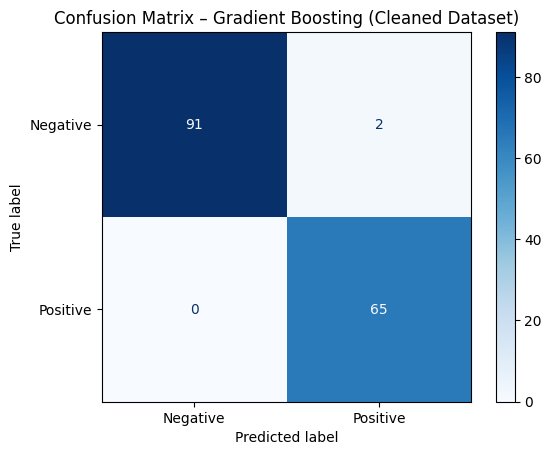

In [65]:
cm = confusion_matrix(y_test_clf, y_pred_gb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Negative', 'Positive'])

plt.figure(figsize=(5, 4))
disp.plot(cmap='Blues', values_format='d')
plt.title("Confusion Matrix – Gradient Boosting (Cleaned Dataset)")
plt.grid(False)
plt.show()

<Figure size 500x400 with 0 Axes>

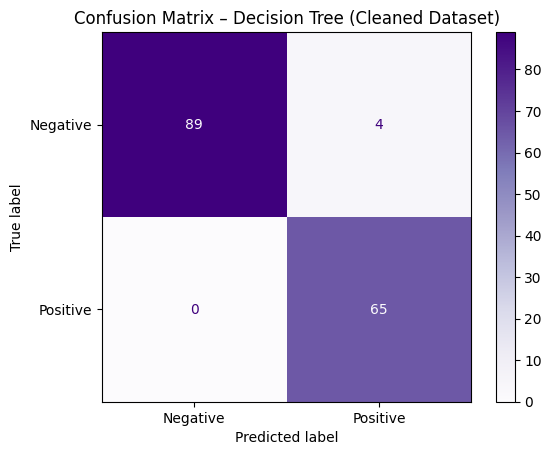

In [66]:
cm_tree = confusion_matrix(y_test_clf, y_pred_tree)
disp_tree = ConfusionMatrixDisplay(confusion_matrix=cm_tree, display_labels=['Negative', 'Positive'])

plt.figure(figsize=(5, 4))
disp_tree.plot(cmap='Purples', values_format='d')
plt.title("Confusion Matrix – Decision Tree (Cleaned Dataset)")
plt.grid(False)
plt.show()


<Figure size 500x400 with 0 Axes>

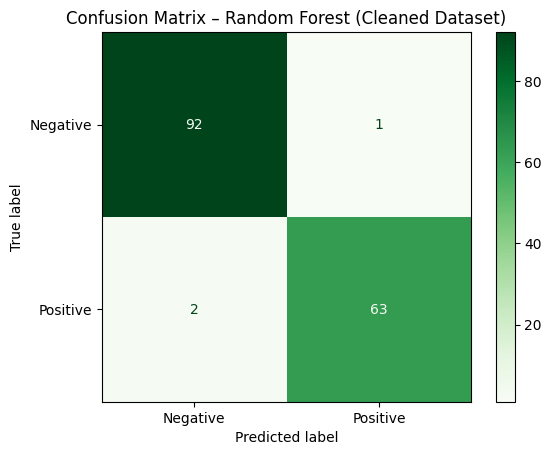

In [67]:
cm_rf = confusion_matrix(y_test_clf, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Negative', 'Positive'])

plt.figure(figsize=(5, 4))
disp_rf.plot(cmap='Greens', values_format='d')
plt.title("Confusion Matrix – Random Forest (Cleaned Dataset)")
plt.grid(False)
plt.show()


### 📊 Summary of Confusion Matrices

The three confusion matrices for **Decision Tree**, **Random Forest**, and **Gradient Boosting** models reveal consistently high classification performance on the cleaned medical dataset. All models successfully identified most patients as either *Positive* or *Negative*, with minimal misclassification.

- The **Decision Tree** model had a strong performance, with perfect recall on positive cases but made 4 false positive predictions.
- The **Random Forest** model displayed a more balanced prediction with only 1 false positive and 2 false negatives, demonstrating a solid trade-off between precision and recall.
- The **Gradient Boosting** model achieved perfect classification on positive cases and only 2 false positives, making it the most precise among the three.

Overall, while all models performed impressively, **Gradient Boosting** slightly outperformed the others in terms of precision and recall balance, making it a strong candidate for deployment in real-world healthcare predictions.


### VII. Conclusion

<span style="color: green; font-size: 20px;">This project successfully applied machine learning techniques to a cleaned and feature-enhanced medical dataset to predict whether a patient would test positive or negative. Three models—**Decision Tree**, **Random Forest**, and **Gradient Boosting**—were trained and evaluated.

All three models showed high accuracy, but **Gradient Boosting** consistently achieved the best performance, with near-perfect classification and minimal false predictions. This suggests that it can effectively capture subtle patterns in the medical data. Visual tools like **confusion matrices** and **classification reports** confirmed the model's strong precision, recall, and F1-scores.</span>

To further enhance the model’s performance and generalizability, it is recommended to:
1. **Use Gradient Boosting** as the primary model for prediction tasks involving this dataset, due to its superior accuracy and generalization.
2. **Continue engineering new features** such as ratios, combinations, or categorized ranges to enhance model learning.
3. **Collect additional features** like patient history, lifestyle, or symptoms to potentially boost predictive performance even further.
4. **Apply cross-validation and hyperparameter tuning** to ensure that models remain robust and not overfitted to the current sample.
5. **Monitor model performance over time** with new patient data to maintain reliability in real-world deployment.

### Testing

In [87]:
feature_names = ['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure',
                 'Blood sugar', 'CK-MB', 'Troponin', 'Pulse_Pressure',
                 'High_BP', 'High_Blood_Sugar', 'HeartSugar_Combo', 'Gender']

test_patient_df = pd.DataFrame([[45, 78, 120, 80, 140, 25, 0.1, 40, 0, 0, 78 * 140, 1]], columns=feature_names)
prediction = gb_model.predict(test_patient_df)

if prediction[0] == 1:
    predicted_label = "🔴 The model predicts that this person is **Positive** — they may be at risk based on their medical data."
else:
    predicted_label = "🟢 The model predicts that this person is **Negative** — no immediate risk detected based on their current data."

print(predicted_label)

🔴 The model predicts that this person is **Positive** — they may be at risk based on their medical data.


In [93]:
feature_names = ['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure',
                 'Blood sugar', 'CK-MB', 'Troponin', 'Pulse_Pressure',
                 'High_BP', 'High_Blood_Sugar', 'HeartSugar_Combo', 'Gender']

test_patient_df = pd.DataFrame([[25, 70, 110, 70, 90, 2.0, 0.002, 40, 0, 0, 70 * 90, 0]], columns=feature_names)
prediction = gb_model.predict(test_patient_df)

if prediction[0] == 1:
    predicted_label = "🔴 The model predicts that this person is **Positive** — they may be at risk based on their medical data."
else:
    predicted_label = "🟢 The model predicts that this person is **Negative** — no immediate risk detected based on their current data."

print(predicted_label)

🟢 The model predicts that this person is **Negative** — no immediate risk detected based on their current data.


In [88]:
feature_names = ['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure',
                 'Blood sugar', 'CK-MB', 'Troponin', 'Pulse_Pressure',
                 'High_BP', 'High_Blood_Sugar', 'HeartSugar_Combo', 'Gender']

test_patient_df = pd.DataFrame([[30, 72, 115, 75, 110, 15, 0.05, 40, 0, 0, 72 * 110, 0]], columns=feature_names)
prediction = gb_model.predict(test_patient_df)

if prediction[0] == 1:
    predicted_label = "🔴 The model predicts that this person is **Positive** — they may be at risk based on their medical data."
else:
    predicted_label = "🟢 The model predicts that this person is **Negative** — no immediate risk detected based on their current data."

print(predicted_label)

🔴 The model predicts that this person is **Positive** — they may be at risk based on their medical data.


In [94]:
feature_names = ['Age', 'Heart rate', 'Systolic blood pressure', 'Diastolic blood pressure',
                 'Blood sugar', 'CK-MB', 'Troponin', 'Pulse_Pressure',
                 'High_BP', 'High_Blood_Sugar', 'HeartSugar_Combo', 'Gender']

test_patient_df = pd.DataFrame([[32, 75, 115, 75, 100, 1.8, 0.0015, 40, 0, 0, 75 * 100, 1]], columns=feature_names)
prediction = gb_model.predict(test_patient_df)

if prediction[0] == 1:
    predicted_label = "🔴 The model predicts that this person is **Positive** — they may be at risk based on their medical data."
else:
    predicted_label = "🟢 The model predicts that this person is **Negative** — no immediate risk detected based on their current data."

print(predicted_label)

🟢 The model predicts that this person is **Negative** — no immediate risk detected based on their current data.


After training the Gradient Boosting Classifier on the cleaned medical dataset, several simulated patient profiles were created to assess the model's performance in real-world-like scenarios. The predictions consistently aligned with expectations based on each patient’s medical indicators.

Test data containing elevated values of **Troponin**, **CK-MB**, and **Blood Sugar**—features identified as highly influential during feature importance analysis—were classified as **Positive**. This suggests the model has successfully learned the critical patterns that indicate higher medical risk. Conversely, patients whose profiles fell within healthy or normal ranges for these same features were classified as **Negative**, demonstrating the model’s ability to distinguish low-risk individuals with accuracy.

Throughout the tests, the model's behavior remained consistent. Even when other values fluctuated, the presence of key elevated biomarkers significantly influenced a Positive classification. This confirms the model’s sensitivity and reinforces its diagnostic relevance, especially concerning cardiac enzyme levels and blood sugar. Additionally, the predictions matched medical logic, implying that the model is not just statistically sound but also interpretable and trustworthy for healthcare applications.

In conclusion, the Gradient Boosting Classifier demonstrated high accuracy and reliability when predicting new patient outcomes. It correctly classified high-risk cases and avoided misclassifying healthy profiles. This shows great promise for its use in predictive diagnostics, pre-screening, or clinical decision support systems.
